# 3. Big Birds Attention (Dikkat)

'Yapay zeka modelleri uzun metinleri işlerken hesaplama maliyeti nedeniyle zorlanır' cümlesi için Attention Mekanizmaları Analizi
BigBird Parametreleri -> Pencere: 2, Rastgele: 2, Genel: [0]
BigBird Maskesi Oluşturuluyor...
Analiz tamamlandı. Karşılaştırma grafiği oluşturuluyor...

Uyarı: 'DejaVu Sans' fontu bulunamadı. Görseldeki etiketler düzgün görünmeyebilir.



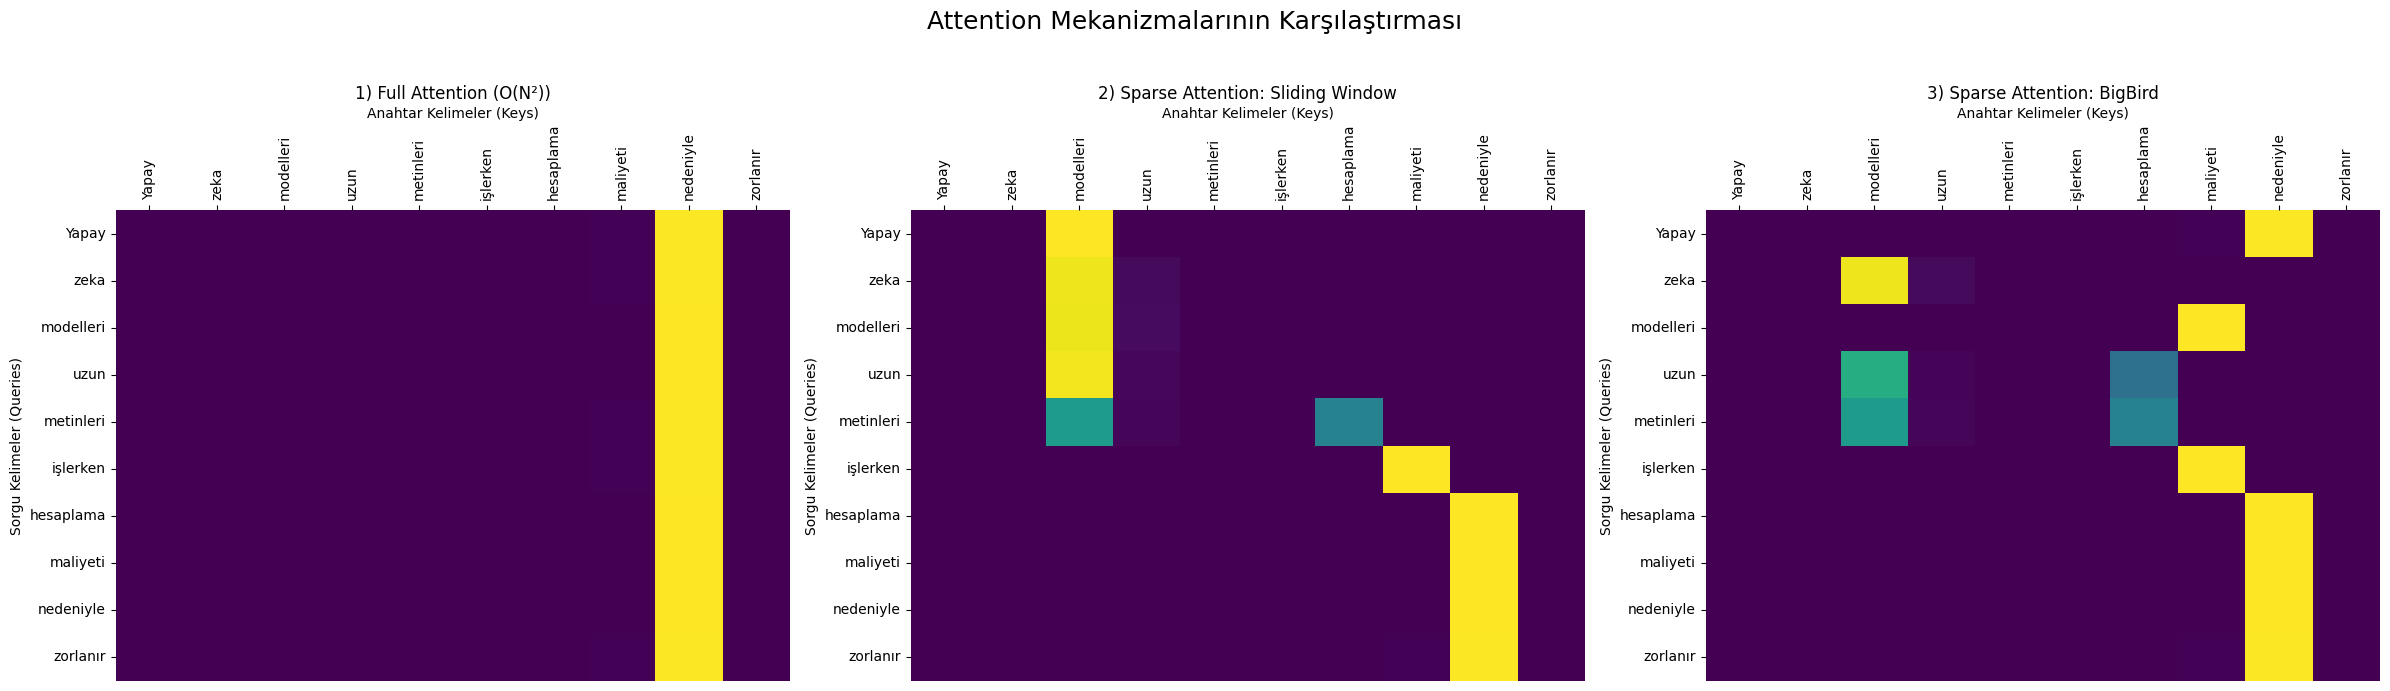

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- Önceki kodlardan alınan yardımcı fonksiyonlar ---
def softmax(x):
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / np.sum(e_x, axis=-1, keepdims=True)

# --- BigBird için yeni maske oluşturma fonksiyonları ---

def create_sliding_window_mask(sequence_length, window_size):
    """Kayan pencere için maske oluşturur."""
    mask = np.full((sequence_length, sequence_length), -np.inf)
    for i in range(sequence_length):
        start = max(0, i - window_size)
        end = min(sequence_length, i + window_size + 1)
        mask[i, start:end] = 0
    return mask

def create_random_mask(sequence_length, num_random_tokens, window_size):
    """Rastgele dikkat için maske oluşturur."""
    mask = np.full((sequence_length, sequence_length), -np.inf)
    for i in range(sequence_length):
        # Rastgele indisleri seç
        random_indices = np.random.choice(sequence_length, num_random_tokens, replace=False)
        mask[i, random_indices] = 0
    return mask

def create_global_mask(sequence_length, global_indices):
    """Genel dikkat için maske oluşturur."""
    mask = np.full((sequence_length, sequence_length), -np.inf)
    # Global token'ların olduğu satır ve sütunları tamamen aç
    mask[global_indices, :] = 0
    mask[:, global_indices] = 0
    return mask

# --- YENİ 3'LÜ KARŞILAŞTIRMA GÖRSELLEŞTİRME FONKSİYONU ---
def visualize_bigbird_comparison(sentence, full_att, window_att, bigbird_att):
    """Üç dikkat matrisini yan yana görselleştirir."""
    try:
        font_prop = fm.FontProperties(fname='/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', size=9)
        plt.rcParams['font.family'] = font_prop.get_name()
    except:
        print("\nUyarı: 'DejaVu Sans' fontu bulunamadı. Görseldeki etiketler düzgün görünmeyebilir.\n")
    
    tokens = sentence.split()
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    
    # Grafik 1: Full Attention
    sns.heatmap(full_att, xticklabels=tokens, yticklabels=tokens, annot=False, cmap="viridis", ax=axes[0], cbar=False)
    axes[0].set_title("1) Full Attention (O(N²))")
    
    # Grafik 2: Sliding Window Attention
    sns.heatmap(window_att, xticklabels=tokens, yticklabels=tokens, annot=False, cmap="viridis", ax=axes[1], cbar=False)
    axes[1].set_title("2) Sparse Attention: Sliding Window")

    # Grafik 3: BigBird Attention
    sns.heatmap(bigbird_att, xticklabels=tokens, yticklabels=tokens, annot=False, cmap="viridis", ax=axes[2], cbar=False)
    axes[2].set_title("3) Sparse Attention: BigBird")

    for ax in axes:
        ax.set_xlabel("Anahtar Kelimeler (Keys)")
        ax.set_ylabel("Sorgu Kelimeler (Queries)")
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')
        plt.setp(ax.get_xticklabels(), rotation=90)


    fig.suptitle("Attention Mekanizmalarının Karşılaştırması", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

def bigbird_attention_demo(sentence, window_size=1, num_random_tokens=1, global_indices=[0]):
    """
    Full, Sliding Window ve BigBird Attention mekanizmalarını karşılaştırır.
    """
    print(f"'{sentence}' cümlesi için Attention Mekanizmaları Analizi")
    print(f"BigBird Parametreleri -> Pencere: {window_size}, Rastgele: {num_random_tokens}, Genel: {global_indices}")
    print("=" * 80)
    
    tokens = sentence.split()
    seq_len = len(tokens)
    
    # Adım 1-4: Ortak Hesaplamalar
    d_model, d_k = 32, 8
    np.random.seed(42)
    embeddings = np.random.rand(seq_len, d_model)
    W_q, W_k, W_v = [np.random.rand(d_model, d_k) for _ in range(3)]
    Q, K, V = embeddings @ W_q, embeddings @ W_k, embeddings @ W_v
    scaled_scores = (Q @ K.T) / np.sqrt(d_k)
    
    # 1. YOL: FULL ATTENTION
    full_attention_weights = softmax(scaled_scores)
    
    # 2. YOL: SLIDING WINDOW ATTENTION
    window_mask = create_sliding_window_mask(seq_len, window_size)
    window_attention_weights = softmax(scaled_scores + window_mask)
    
    # 3. YOL: BIGBIRD ATTENTION
    print("BigBird Maskesi Oluşturuluyor...")
    # Üç farklı maskeyi oluştur
    mask1_window = create_sliding_window_mask(seq_len, window_size)
    mask2_random = create_random_mask(seq_len, num_random_tokens, window_size)
    mask3_global = create_global_mask(seq_len, global_indices)
    
    # Maskeleri birleştir. Bir pozisyona herhangi bir maske izin veriyorsa (0 ise),
    # o pozisyon açık kalmalıdır.
    bigbird_mask = np.maximum.reduce([mask1_window, mask2_random, mask3_global])
    
    # BigBird ağırlıklarını hesapla
    bigbird_attention_weights = softmax(scaled_scores + bigbird_mask)
    
    print("Analiz tamamlandı. Karşılaştırma grafiği oluşturuluyor...")
    
    # Sonuçları görselleştir
    visualize_bigbird_comparison(sentence, full_attention_weights, window_attention_weights, bigbird_attention_weights)


if __name__ == '__main__':
    ornek_cumle = "Yapay zeka modelleri uzun metinleri işlerken hesaplama maliyeti nedeniyle zorlanır"
    
    # BigBird Parametreleri
    pencere_boyutu = 2       # Her kelime sağına/soluna 2 kelimeye bakar
    rastgele_token_sayisi = 2 # Her kelime rastgele 2 kelimeye daha bakar
    genel_token_indisleri = [0] # İlk kelime ('Yapay') genel token'dır
    
    bigbird_attention_demo(ornek_cumle, pencere_boyutu, rastgele_token_sayisi, genel_token_indisleri)